In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics & Utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.max_columns', 200)




In [74]:
url ='/content/Bank Customer Churn Prediction.csv'

df = pd.read_csv(url)
print(df.head())

print(df.columns)
print(df.shape)

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_ca

In [75]:
print(df.info())
display(df.describe(include='all').T)

# Missing value
print(df.isnull().sum())

# Distribution target

print("\nChurn value counts: ")
print(df['churn'].value_counts(normalize=False))
print("\nChurn proportion: ")
print(df['churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0


customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Churn value counts: 
churn
0    7963
1    2037
Name: count, dtype: int64

Churn proportion: 
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


      credit_score  age  tenure    balance  products_number  estimated_salary
0              619   42       2       0.00                1         101348.88
1              608   41       1   83807.86                1         112542.58
2              502   42       8  159660.80                3         113931.57
3              699   39       1       0.00                2          93826.63
4              850   43       2  125510.82                1          79084.10
...            ...  ...     ...        ...              ...               ...
9995           771   39       5       0.00                2          96270.64
9996           516   35      10   57369.61                1         101699.77
9997           709   36       7       0.00                1          42085.58
9998           772   42       3   75075.31                2          92888.52
9999           792   28       4  130142.79                1          38190.78

[10000 rows x 6 columns]


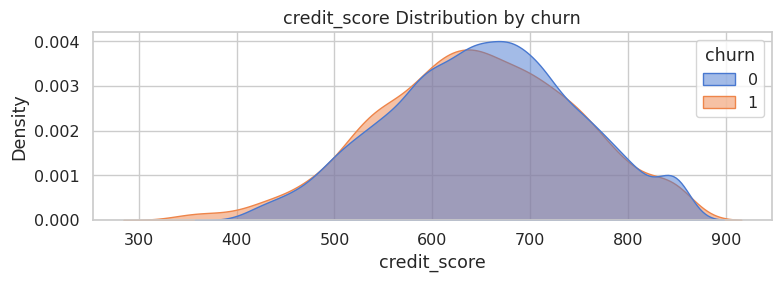

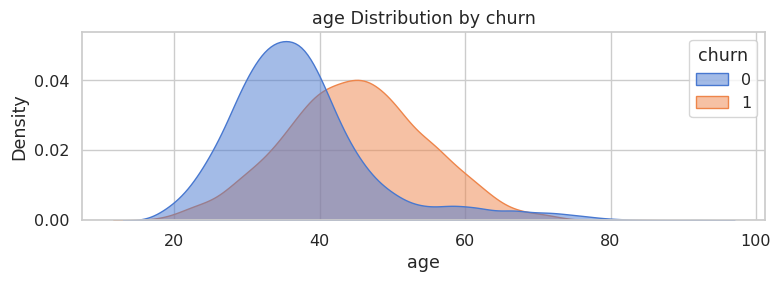

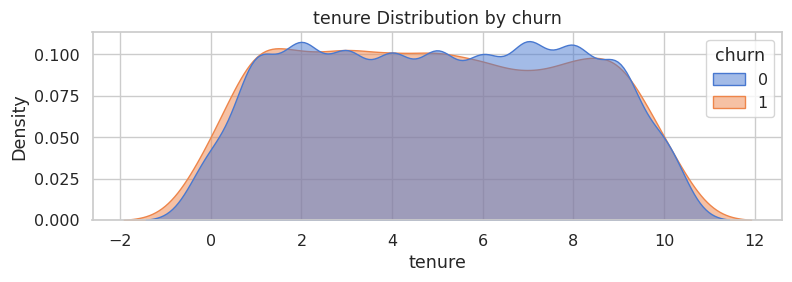

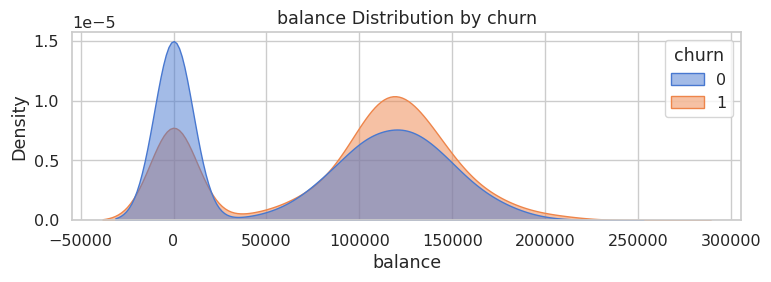

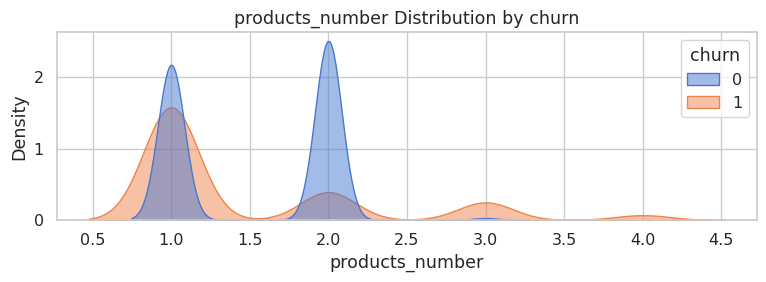

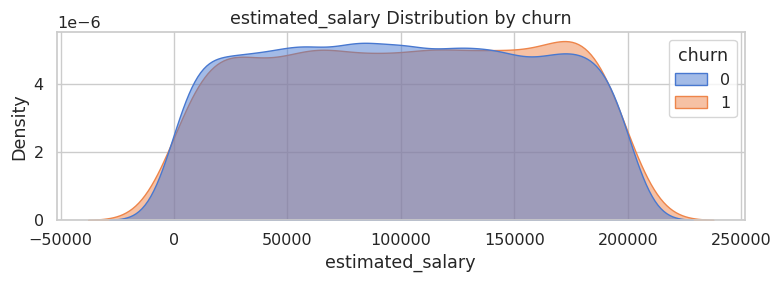

In [76]:
# Exploratory Data Analysis (visualizations)

num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
print(df[num_cols])

for col in num_cols:
  plt.figure(figsize=(8,3))
  sns.kdeplot(data=df, x=col, hue='churn', fill=True, alpha=0.5, common_norm=False)
  plt.title(f"{col} Distribution by churn")
  plt.tight_layout()
  plt.show()




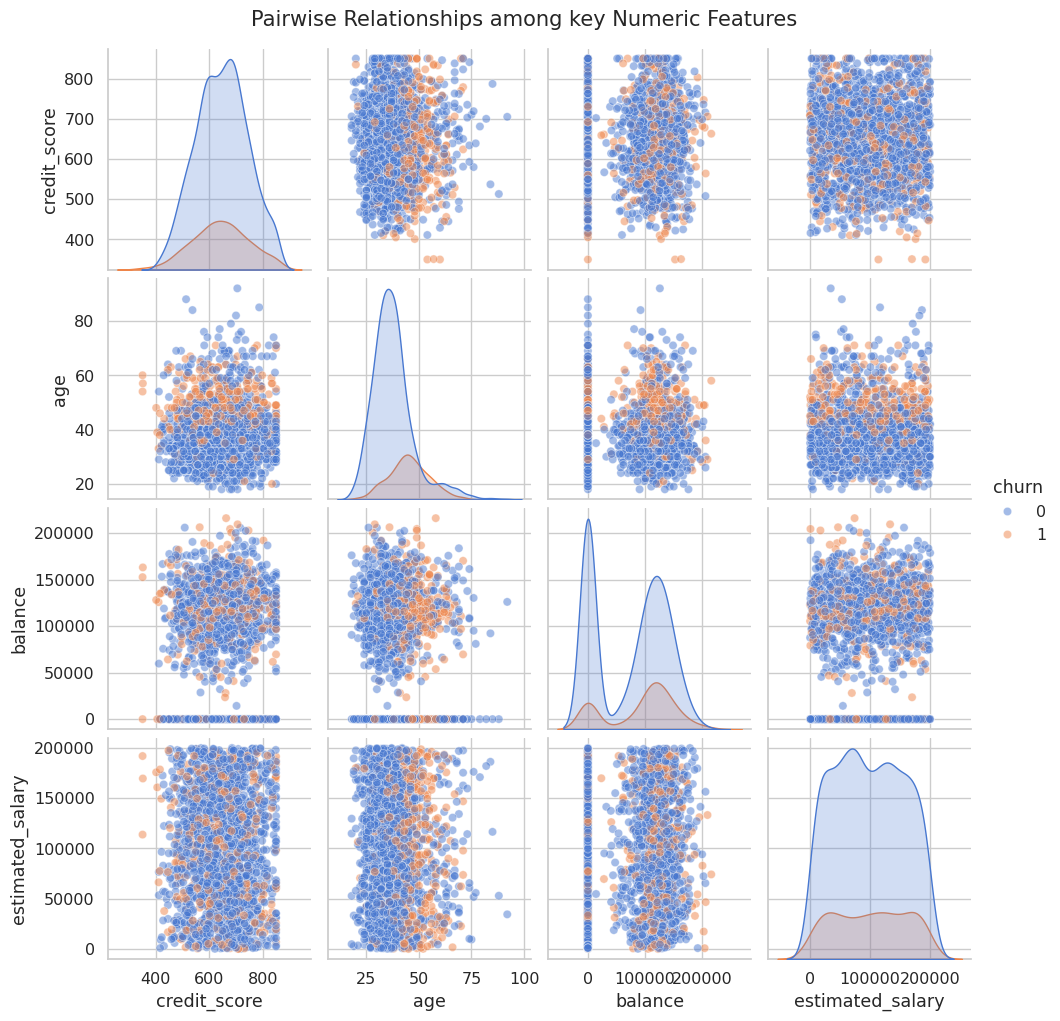

In [77]:
# Pairplot (smapled for speed)

sns.pairplot(df.sample(frac=0.2, random_state=42),
             vars=['credit_score', 'age', 'balance', 'estimated_salary'],
            hue='churn', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships among key Numeric Features', y=1.02)
plt.show()

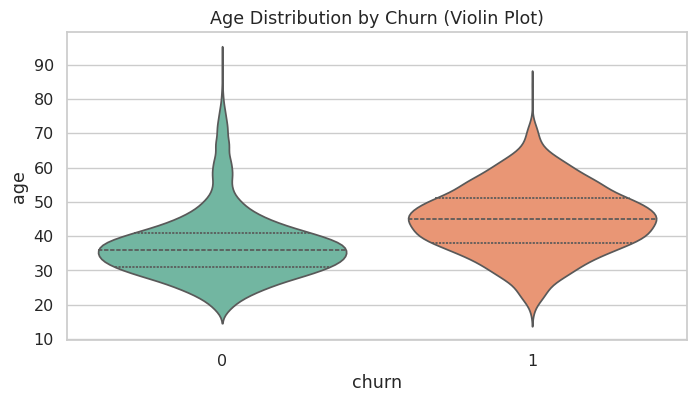

In [78]:
# violin plot for Age

plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='churn', y='age', inner='quart', palette='Set2')
plt.title("Age Distribution by Churn (Violin Plot)")
plt.show()


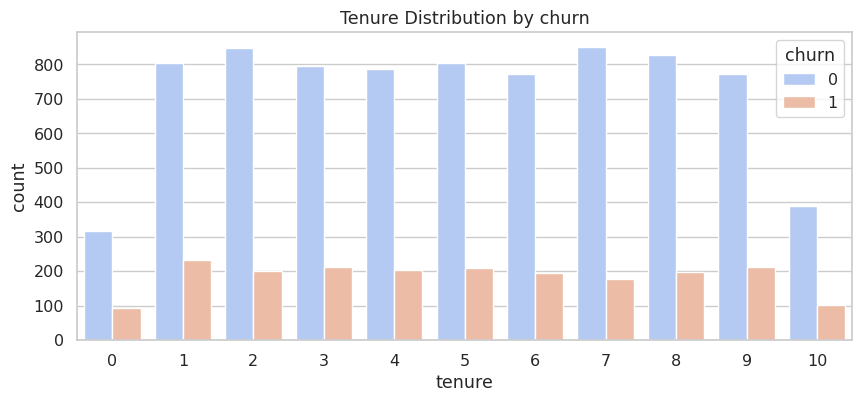

In [79]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='tenure', hue='churn', palette='coolwarm' )
plt.title('Tenure Distribution by churn')
plt.show()

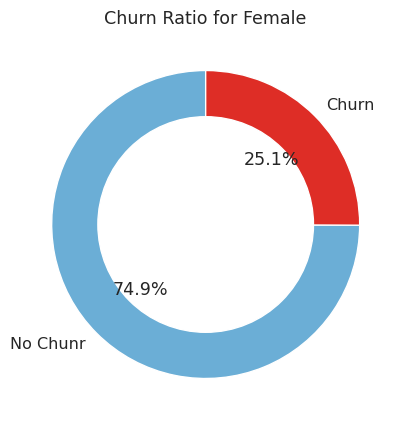

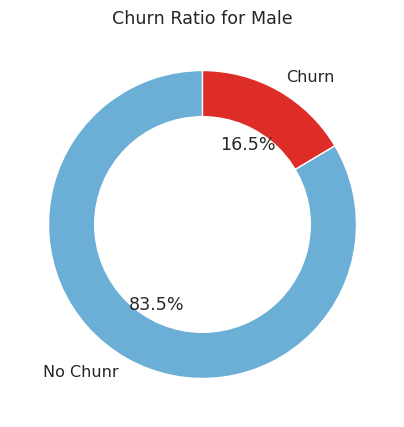

In [80]:
from numpy._core.defchararray import center
gender_counts = df.groupby('gender')['churn'].value_counts(normalize=True).unstack().fillna(0)

for gender in gender_counts.index:
  plt.figure(figsize=(5,5))
  plt.pie(gender_counts.loc[gender], labels=['No Chunr', 'Churn'],
          autopct='%1.1f%%', startangle=90, colors=['#6baed6', '#de2d26'])

  center = plt.Circle((0,0), 0.70, fc='white')
  fig = plt.gcf()
  fig.gca().add_artist(center)
  plt.title(f"Churn Ratio for {gender}")


In [81]:
# Feature Engineering
# used my name: mahabub

mahabub = df.copy()
display(mahabub.head())


mahabub['balance_per_product'] = mahabub['balance'] / (mahabub['products_number'].replace(0, np.nan))
mahabub['balance_per_product'].fillna(0, inplace=True)

mahabub['salary_balance_ratio'] = mahabub['estimated_salary'] / (mahabub['balance'].replace(0, np.nan))
mahabub['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
mahabub['salary_balance_ratio'].fillna(mahabub['salary_balance_ratio'].median(), inplace=True)

# Age Group
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+' ]

mahabub['age_group'] = pd.cut(mahabub['age'], bins=bins, labels=labels)

# Tenure bucket
mahabub['tenure_bucket'] = pd.cut(mahabub['tenure'], bins=[-1, 0, 2, 5, 10, 100], labels=['0', '1-2', '3-5', '6-10', '10+'])

# Flag High balance
mahabub['high_balance'] = (mahabub['balance'] > mahabub['balance'].quantile(0.75).astype(int))

mahabub[['balance_per_product', 'salary_balance_ratio', 'age_group', "tenure_bucket", 'high_balance']].head(20)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


,balance_per_product,salary_balance_ratio,age_group,tenure_bucket,high_balance
0,0.000000,0.839258,35-44,1-2,False
1,83807.860000,1.342864,35-44,1-2,False
2,53220.266667,0.713585,35-44,6-10,True
3,0.000000,0.839258,35-44,1-2,False
4,125510.820000,0.630098,35-44,1-2,False
5,56877.890000,1.316476,35-44,6-10,False
6,0.000000,0.839258,45-54,6-10,False
7,28761.685000,1.037377,25-34,3-5,False
8,71025.535000,0.527560,35-44,3-5,True
9,134603.880000,0.532865,25-34,1-2,True


In [82]:
target = 'churn'
drop_cols = ['customer_id']

features = [c for c in mahabub.columns if c not in [target] + drop_cols]
print(mahabub[features].columns)

numeric_features = ['credit_score','age','tenure','balance','products_number','estimated_salary',
                    'balance_per_product','salary_balance_ratio']
categorical_features = ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']

print("="*60)
print("categorical_features: \n",mahabub[categorical_features])
print("Numeric_features: \n",mahabub[numeric_features])




Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'balance_per_product', 'salary_balance_ratio', 'age_group',
       'tenure_bucket', 'high_balance'],
      dtype='object')
categorical_features: 
       country  gender  credit_card  active_member age_group tenure_bucket  \
0      France  Female            1              1     35-44           1-2   
1       Spain  Female            0              1     35-44           1-2   
2      France  Female            1              0     35-44          6-10   
3      France  Female            0              0     35-44           1-2   
4       Spain  Female            1              1     35-44           1-2   
...       ...     ...          ...            ...       ...           ...   
9995   France    Male            1              0     35-44           3-5   
9996   France    Male            1              1     25-34          6-10   
999

In [83]:
mahabub[categorical_features] = mahabub[categorical_features].astype(object)


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', Categorical_transformer, categorical_features)
])

print("Numeric Features: \n", mahabub[numeric_features])
print("Categorical Features: \n", mahabub[categorical_features])
print(numeric_features)
print(categorical_features)

Numeric Features: 
       credit_score  age  tenure    balance  products_number  estimated_salary  \
0              619   42       2       0.00                1         101348.88   
1              608   41       1   83807.86                1         112542.58   
2              502   42       8  159660.80                3         113931.57   
3              699   39       1       0.00                2          93826.63   
4              850   43       2  125510.82                1          79084.10   
...            ...  ...     ...        ...              ...               ...   
9995           771   39       5       0.00                2          96270.64   
9996           516   35      10   57369.61                1         101699.77   
9997           709   36       7       0.00                1          42085.58   
9998           772   42       3   75075.31                2          92888.52   
9999           792   28       4  130142.79                1          38190.78   

      b

In [84]:
X = mahabub[features]
y = mahabub[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Total Dataset: \n",mahabub.shape)
print("X_train: \n", X_train.shape)
print("y_train: \n", y_train.shape)
print("X_test: \n", X_test.shape)
print("y_test: \n", y_test.shape)


Total Dataset: 
 (10000, 17)
X_train: 
 (8000, 15)
y_train: 
 (8000,)
X_test: 
 (2000, 15)
y_test: 
 (2000,)


In [85]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting':  GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
  pipe = Pipeline(steps=[('preprocessor', preprocessor),
                         ('Classifier', model)])
  scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
  results[name] = scores
  print(f"{name} AUC: Mean={scores.mean():.4f} std={scores.std():.4f}")

LogisticRegression AUC: Mean=0.7877 std=0.0244
RandomForest AUC: Mean=0.8486 std=0.0130
GradientBoosting AUC: Mean=0.8627 std=0.0097
AdaBoost AUC: Mean=0.8462 std=0.0133
SVC AUC: Mean=0.8351 std=0.0104


Text(0.5, 1.0, 'Model comparision (cross_validated Roc Auc)')

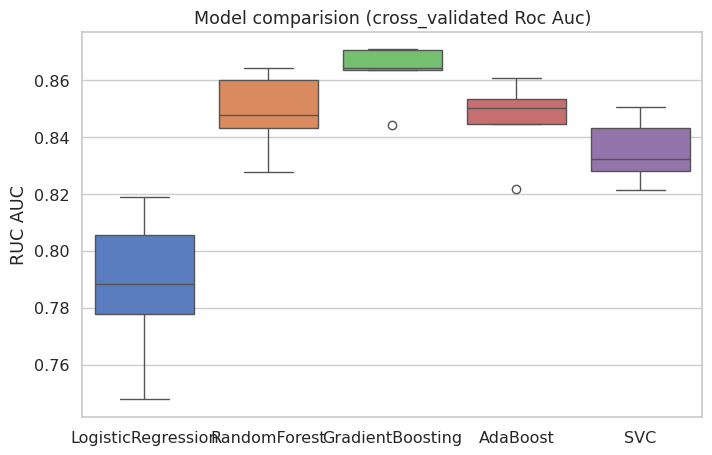

In [86]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel('RUC AUC')
plt.title('Model comparision (cross_validated Roc Auc)')

In [89]:
# chose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', np.float64(0.8627478787645309))

Test Accurecy: 0.8680
Test precision: 0.7804
Test Recall: 0.4889
Test F1: 0.6012
Test Roc: 0.8692
Test Classification:               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

Test confussion metrix: [[1537   56]
 [ 208  199]]


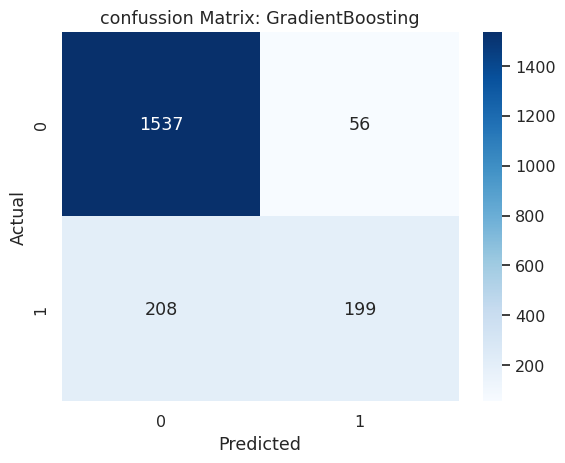

In [90]:
best_model = models[best_name]

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
classrp = classification_report(y_test, y_pred)
conmet = confusion_matrix(y_test, y_pred)


print(f"Test Accurecy: {acc:.4f}")
print(f"Test precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test Roc: {roc:.4f}")

from sklearn.metrics import classification_report, confusion_matrix

print(f"Test Classification: {classrp}")
print(f"Test confussion metrix: {conmet}")


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f'confussion Matrix: {best_name}')
plt.show()

In [92]:
# Save the best Pipeline and proprocessing artifacts

joblib.dump(best_pipeline, "best_churn_pipeline.pkl")
print("Saved pipeline: best_churn_pipline.pdl")

Saved pipeline: best_churn_pipline.pdl


In [91]:
sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)

sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].median(), inplace=True)

bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[-1,0,2,5,10,100], labels=['0','1-2','3-5','6-10','10+'])
sample_df['high_balance'] = (sample_df['balance'] > 50000.0).astype(int)  # can use 75th percentile of training set


sample_df = sample_df.drop(columns=['customer_id'])

pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0,1]

print(f'Predicted churn: {pred}, probability of churn: {prob:.3f}')

Predicted churn: 0, probability of churn: 0.030
